# 04 — Outlier Analysis

**Amaç:** Tekil feature outlier'larını, target ilişkisini ve train/test farkını incelemek. Satır silinmez.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from kaggle_s6_e7.config import (FIGURES_DIR, TABLES_DIR, TARGET_COL, ID_COL,
    PLOT_SAMPLE_SIZE, RANDOM_STATE, ensure_report_dirs)
from kaggle_s6_e7.data import load_competition_data, infer_feature_columns, validate_schema
ensure_report_dirs()
train, test = load_competition_data()
validate_schema(train, test)
cat_cols, num_cols = infer_feature_columns(train)
plot_df = train.sample(min(PLOT_SAMPLE_SIZE, len(train)), random_state=RANDOM_STATE)
sns.set_theme(style="whitegrid")

## IQR ve quantile outlier özeti

In [2]:
from kaggle_s6_e7.eda import outlier_summary
summary=outlier_summary(train,num_cols)
display(summary)
summary.to_csv(TABLES_DIR / "04_outlier_summary.csv")

,iqr_low,iqr_high,iqr_outlier_rate,quantile_low,quantile_high,quantile_outlier_rate
feature,,,,,,
sleep_duration,3.685,10.285,0.002927,3.85,9.96,0.008435
heart_rate,52.450,97.650,0.004094,54.00,95.30,0.009696
bmi,16.310,29.670,0.007756,16.55,29.40,0.009671
calorie_expenditure,1448.500,3060.500,0.018593,1312.00,3093.00,0.009092
step_count,-4698.500,22201.500,0.000000,1136.00,14863.00,0.009626
exercise_duration,-1.100,79.700,0.000151,0.00,70.10,0.004883
water_intake,0.850,3.490,0.016502,0.66,3.56,0.008922


## Train/test quantile outlier oranları

In [3]:
from kaggle_s6_e7.features import fit_outlier_bounds, add_outlier_flags
bounds=fit_outlier_bounds(train,num_cols)
train_flags=add_outlier_flags(train,bounds); test_flags=add_outlier_flags(test,bounds)
flag_cols=[c for c in train_flags if c.endswith(("_outlier_low","_outlier_high"))]
comparison=pd.DataFrame({"train_rate":train_flags[flag_cols].mean(),"test_rate":test_flags[flag_cols].mean()})
comparison["delta"]=comparison.test_rate-comparison.train_rate
display(comparison); comparison.to_csv(TABLES_DIR / "04_train_test_outlier_rates.csv")

,train_rate,test_rate,delta
sleep_duration_outlier_low,0.004386,0.004423,0.000036
sleep_duration_outlier_high,0.004049,0.003997,-0.000052
heart_rate_outlier_low,0.004794,0.003760,-0.001034
heart_rate_outlier_high,0.004902,0.004419,-0.000483
bmi_outlier_low,0.004827,0.004669,-0.000157
bmi_outlier_high,0.004844,0.004801,-0.000043
calorie_expenditure_outlier_low,0.004534,0.004568,0.000034
calorie_expenditure_outlier_high,0.004557,0.004673,0.000115
step_count_outlier_low,0.004886,0.004862,-0.000024
step_count_outlier_high,0.004740,0.004828,0.000088


## Outlier-target ilişkisi

In [4]:
tables=[]
for col in flag_cols:
    table=pd.crosstab(train_flags[col],train_flags[TARGET_COL],normalize="index")
    table.insert(0,"flag",col); tables.append(table.reset_index())
outlier_target=pd.concat(tables,ignore_index=True)
display(outlier_target)
outlier_target.to_csv(TABLES_DIR / "04_outlier_target.csv",index=False)

health_condition,sleep_duration_outlier_low,flag,at-risk,fit,unhealthy,sleep_duration_outlier_high,heart_rate_outlier_low,heart_rate_outlier_high,bmi_outlier_low,bmi_outlier_high,calorie_expenditure_outlier_low,calorie_expenditure_outlier_high,step_count_outlier_low,step_count_outlier_high,exercise_duration_outlier_low,exercise_duration_outlier_high,water_intake_outlier_low,water_intake_outlier_high
0,0.0,sleep_duration_outlier_low,0.859911,0.057926,0.082163,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,sleep_duration_outlier_low,0.578130,0.001321,0.420548,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,sleep_duration_outlier_high,0.858494,0.057524,0.083982,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,sleep_duration_outlier_high,0.903006,0.095562,0.001432,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,heart_rate_outlier_low,0.858506,0.057691,0.083803,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,heart_rate_outlier_low,0.893591,0.055018,0.051391,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,heart_rate_outlier_high,0.858669,0.057640,0.083691,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,heart_rate_outlier_high,0.859888,0.065327,0.074786,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,bmi_outlier_low,0.860396,0.055551,0.084053,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,bmi_outlier_low,0.503753,0.496247,0.000000,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Row-level outlier count

health_condition,at-risk,fit,unhealthy
outlier_count,,,
0,0.865035,0.054990,0.079975
1,0.759788,0.099302,0.140910
2,0.650162,0.151786,0.198052
3,0.428571,0.190476,0.380952


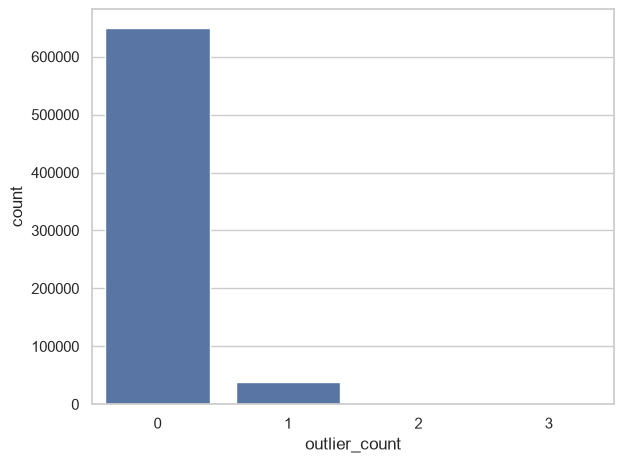

In [5]:
display(pd.crosstab(train_flags.outlier_count,train_flags[TARGET_COL],normalize="index"))
sns.countplot(data=train_flags,x="outlier_count")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "04_outlier_count.png",dpi=150); plt.show()

## Varsayılan karar
- Outlier nedeniyle satır silme yok.
- Train quantile eşiklerinden flag üretimi V2 adayıdır.
- %0.1–%99.9 clipping yalnız V3 deneyidir.